# Cartoonizer
Upload a selfie, describe your mood, and get a cartoon + mood quote!


**Mounting Drive**

In [1]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


**DATA PREPARATION**

In [ ]:
#dont need to run this its only for the first time

# Clone U-GAT-IT
!git clone https://github.com/znxlwm/UGATIT-pytorch /content/UGATIT

# dependencies
!pip install torch torchvision pillow matplotlib tqdm transformers gradio --quiet


Cloning into '/content/UGATIT'...
remote: Enumerating objects: 70, done.
remote: Total 70 (delta 0), reused 0 (delta 0), pack-reused 70 (from 1)
Receiving objects: 100% (70/70), 4.31 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (23/23), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Dont download Downloading Images - only require for running first time

import os, requests
from PIL import Image
from io import BytesIO

# Create dataset folders
folders = [
    "trainA/real", "trainB/cartoon",
    "testA", "testB"
]
for folder in folders:
    os.makedirs(f"/content/UGATIT/dataset/selfie2anime/{folder}", exist_ok=True)

# Real faces
for i in range(1000):
    r = requests.get("https://thispersondoesnotexist.com", headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(BytesIO(r.content)).convert("RGB").resize((256, 256))
    img.save(f"/content/UGATIT/dataset/selfie2anime/trainA/real/{i:04d}.jpg")

# Cartoon faces
'''for i in range(50):
    try:
        resp = requests.get("https://api.waifu.pics/sfw/waifu")
        url = resp.json()["url"]
        img_data = requests.get(url).content
        img = Image.open(BytesIO(img_data)).convert("RGB").resize((256, 256))
        img.save(f"/content/UGATIT/dataset/selfie2anime/trainB/cartoon/{i:04d}.jpg")
    except:
        continue'''

for i in range(1000):
    try:
        url = "https://www.thiswaifudoesnotexist.net/example-{}.jpg".format(i)
        img_data = requests.get(url).content
        img = Image.open(BytesIO(img_data)).convert("RGB").resize((256, 256))
        img.save(f"/content/UGATIT/dataset/selfie2anime/trainB/cartoon/{i:04d}.jpg")
    except:
        continue


In [ ]:
import os
os.chdir("/content/drive/MyDrive/cartoonify_50000/UGATIT")


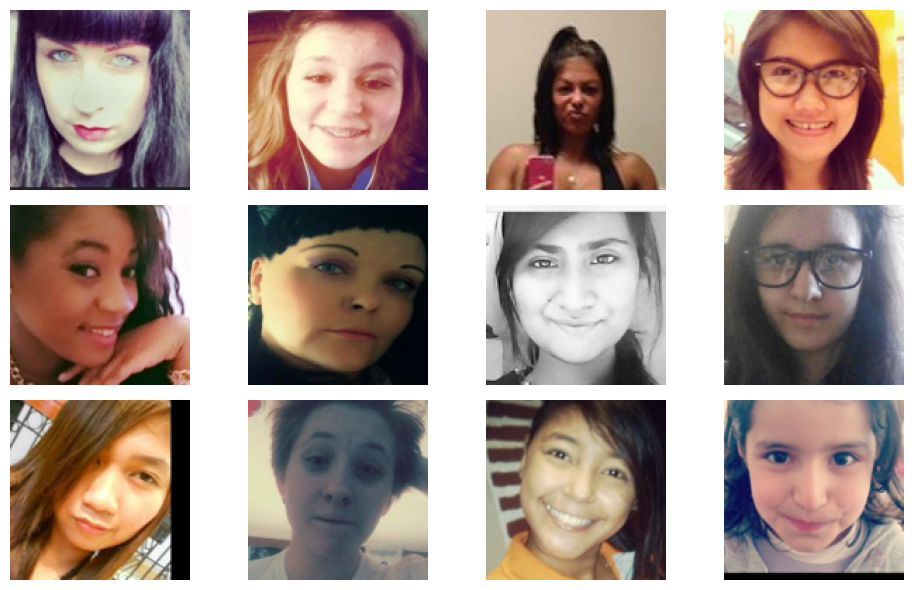

In [ ]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify_50000/UGATIT/dataset/selfie2anime/trainA'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()


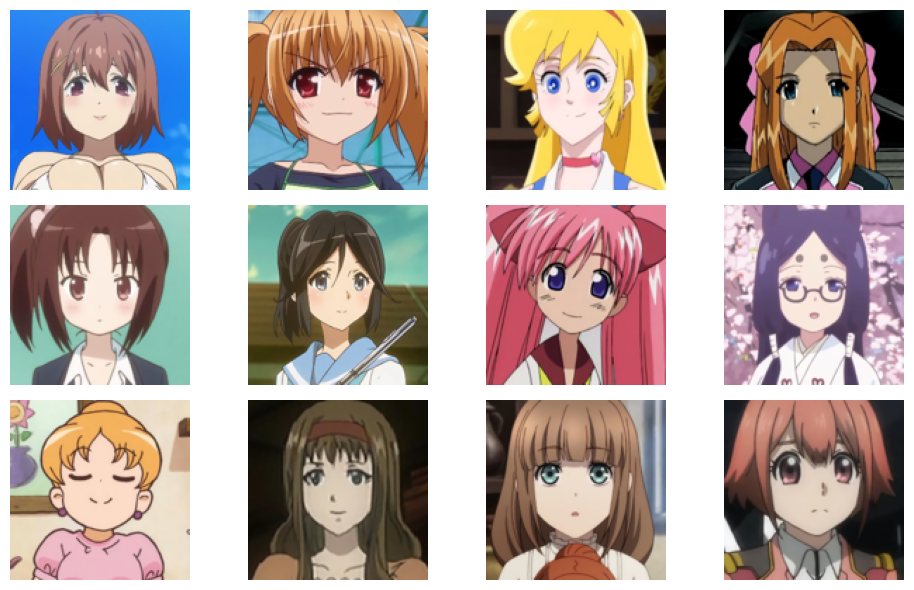

In [ ]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify_50000/UGATIT/dataset/selfie2anime/trainB'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#dont need to run this
import os
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testB", exist_ok=True)


In [ ]:
#dont need to run thi
from PIL import Image
import os

# Create a dummy white image
dummy = Image.new('RGB', (256, 256), color = 'white')

# Save into both testA and testB folders
os.makedirs("/content/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/UGATIT/dataset/selfie2anime/testB", exist_ok=True)
dummy.save("/content/UGATIT/dataset/selfie2anime/testA/dummy.jpg")
dummy.save("/content/UGATIT/dataset/selfie2anime/testB/dummy.jpg")


In [2]:
#Run 2
# Ensure you're in the correct working directory
import os
os.chdir('/content/drive/MyDrive/cartoonify_50000/UGATIT')
# Re-import everything fresh
from UGATIT import UGATIT
from argparse import Namespace
import torch


In [3]:
#Run 3
import os
os.chdir("/content/drive/MyDrive/cartoonify_50000/UGATIT")

# Configurations
config = Namespace(
    dataset='selfie2anime',
    phase='train',
    light=False,
    ch=64,
    n_res=6,
    n_dis=6,
    img_size=256,
    img_ch=3,
    batch_size=4,
    iteration=50000,
    print_freq=100,
    save_freq=1000,
    decay_flag=True,
    lr=0.0001,
    weight_decay=0.0001,
    adv_weight=1,
    cycle_weight=10,
    identity_weight=10,
    cam_weight=1000,
    result_dir='results/selfie2anime',
    checkpoint_dir='checkpoint/selfie2anime',
    log_dir='log/selfie2anime',
    sample_dir='sample/selfie2anime',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    benchmark_flag=True,
    resume=None
)



In [4]:
#Run 4
model = UGATIT(config)
model.build_model()

# Verify
print(" Generator:", hasattr(model, 'generatorA2B'))
print(" Discriminator:", hasattr(model, 'discriminatorA'))

# Print attributes defined in the model
print("Model attributes:")
print([attr for attr in dir(model) if not attr.startswith('_')])


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  50000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
 Generator: False
 Discriminator: False
Model attributes:
['BCE_loss', 'D_optim', 'G_optim', 'L1_loss', 'MSE_loss', 'Rho_clipper', 'adv_weight', 'batch_size', 'benchmark_flag', 'build_model', 'cam_weight', 'ch', 'cycle_weight', 'dataset', 'decay_flag', 'device', 'disGA', 'disGB', 'disLA', 'disLB', 'genA2B', 'genB2A', 'identity_weight', 'img_ch', 'img_size', 'iteration', 'light', 'load', 'lr', 'model_name', 'n_dis', 'n_res', 'print_freq', 'result_dir', 'resume', 'save', 'save_freq', 'test', 'testA', 'testA_loader', 'testB', 'testB_loader', 'train', 'trainA', 'trainA_loader', 'trainB', 'trainB_loader', 'weight_decay']


In [5]:
#Run 5

import os
import torch
import random
import numpy as np
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Mixed precision setup
scaler = GradScaler()

# Safe forward helper
def safe_forward(out):
    return out if isinstance(out, torch.Tensor) else out[0]

# Checkpoint save/load
def save_checkpoint(model, step, path='checkpoint.pth'):
    torch.save({
        'step': step,
        'genA2B': model.genA2B.state_dict(),
        'genB2A': model.genB2A.state_dict(),
        'disGA': model.disGA.state_dict(),
        'disGB': model.disGB.state_dict(),
        'G_optim': model.G_optim.state_dict(),
        'D_optim': model.D_optim.state_dict(),
        'scaler': scaler.state_dict()
    }, path)
    print(f"Checkpoint saved at step {step}")

def load_checkpoint(model, path='checkpoint.pth'):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=model.device)
        model.genA2B.load_state_dict(checkpoint['genA2B'])
        model.genB2A.load_state_dict(checkpoint['genB2A'])
        model.disGA.load_state_dict(checkpoint['disGA'])
        model.disGB.load_state_dict(checkpoint['disGB'])
        model.G_optim.load_state_dict(checkpoint['G_optim'])
        model.D_optim.load_state_dict(checkpoint['D_optim'])
        scaler.load_state_dict(checkpoint['scaler'])
        print(f"Resumed from step {checkpoint['step']}")
        return checkpoint['step']
    return 0

# Resume if checkpoint exists
start_step = load_checkpoint(model, path='checkpoint.pth')

# Training mode ===
model.genA2B.train()
model.genB2A.train()
model.disGA.train()
model.disGB.train()
model.disLA.train()
model.disLB.train()

# Loaders
trainA_iter = iter(model.trainA_loader)
trainB_iter = iter(model.trainB_loader)

print("training loop starting.....")

try:
    for step in tqdm(range(start_step, config.iteration), initial=start_step):
        try:
            real_A, _ = next(trainA_iter)
        except StopIteration:
            trainA_iter = iter(model.trainA_loader)
            real_A, _ = next(trainA_iter)

        try:
            real_B, _ = next(trainB_iter)
        except StopIteration:
            trainB_iter = iter(model.trainB_loader)
            real_B, _ = next(trainB_iter)

        real_A = real_A.to(model.device, non_blocking=True)
        real_B = real_B.to(model.device, non_blocking=True)

        with autocast():
            # Generator forward
            fake_B = safe_forward(model.genA2B(real_A))
            fake_A = safe_forward(model.genB2A(real_B))

            # Cycle reconstruction
            recon_A = safe_forward(model.genB2A(fake_B))
            recon_B = safe_forward(model.genA2B(fake_A))

            # Identity losses
            idt_A = safe_forward(model.genB2A(real_A))
            idt_B = safe_forward(model.genA2B(real_B))

            cycle_loss = model.L1_loss(recon_A, real_A) + model.L1_loss(recon_B, real_B)
            identity_loss = model.L1_loss(idt_A, real_A) + model.L1_loss(idt_B, real_B)

            pred_fake_A = safe_forward(model.disGA(fake_A))
            pred_fake_B = safe_forward(model.disGB(fake_B))

            valid_A = torch.ones_like(pred_fake_A, device=model.device)
            valid_B = torch.ones_like(pred_fake_B, device=model.device)

            adv_loss = model.MSE_loss(pred_fake_A, valid_A) + model.MSE_loss(pred_fake_B, valid_B)

            G_loss = (
                config.cycle_weight * cycle_loss +
                config.identity_weight * identity_loss +
                config.adv_weight * adv_loss
            )

        model.G_optim.zero_grad()
        scaler.scale(G_loss).backward()
        scaler.step(model.G_optim)

        # Discriminator forward
        with autocast():
            pred_real_A = safe_forward(model.disGA(real_A))
            pred_real_B = safe_forward(model.disGB(real_B))

            fake_A = fake_A.detach()
            fake_B = fake_B.detach()

            pred_fake_A_D = safe_forward(model.disGA(fake_A))
            loss_D_A = 0.5 * (
                model.MSE_loss(pred_real_A, torch.ones_like(pred_real_A, device=model.device)) +
                model.MSE_loss(pred_fake_A_D, torch.zeros_like(pred_fake_A_D, device=model.device))
            )

            pred_fake_B_D = safe_forward(model.disGB(fake_B))
            loss_D_B = 0.5 * (
                model.MSE_loss(pred_real_B, torch.ones_like(pred_real_B, device=model.device)) +
                model.MSE_loss(pred_fake_B_D, torch.zeros_like(pred_fake_B_D, device=model.device))
            )

            D_loss = loss_D_A + loss_D_B

        model.D_optim.zero_grad()
        scaler.scale(D_loss).backward()
        scaler.step(model.D_optim)
        scaler.update()

        # Logging
        if (step + 1) % config.print_freq == 0:
            print(f"Step {step+1}/{config.iteration} | G_loss: {G_loss.item():.4f} | D_loss: {D_loss.item():.4f}")

        # Checkpointing
        if (step + 1) % config.save_freq == 0:
            save_checkpoint(model, step + 1, path='checkpoint.pth')

        # torch.cuda.empty_cache()  # if GPU memory is tight
        del real_A, real_B, fake_A, fake_B

except KeyboardInterrupt:
    print("Training interrupted by user.")
    save_checkpoint(model, step, path='checkpoint.pth')

print("Training complete.")


/tmp/ipython-input-5-957673687.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Resumed from step 50000
training loop starting.....


50000it [00:00, ?it/s]

Training complete.


In [6]:
#Run 6
torch.save(model.genA2B.state_dict(), "genA2B_final.pth")
torch.save(model.genB2A.state_dict(), "genB2A_final.pth")
torch.save(model.disGA.state_dict(), "disGA_final.pth")
torch.save(model.disGB.state_dict(), "disGB_final.pth")
torch.save(model.disLA.state_dict(), "disLA_final.pth")
torch.save(model.disLB.state_dict(), "disLB_final.pth")


In [7]:
#Run 6
import torch
import os

def get_trained_step(path='checkpoint.pth', device='cpu'):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        step = checkpoint.get('step', None)
        if step is not None:
            print(f"Model was trained up to step: {step}")
        else:
            print("Step information not found in checkpoint.")
    else:
        print("Checkpoint file does not exist.")

# Example usage
get_trained_step('checkpoint.pth', device='cuda' if torch.cuda.is_available() else 'cpu')


Model was trained up to step: 50000


In [8]:
#Run 7

def infer_single_image(self, input_path, save_path):
    from PIL import Image
    import torchvision.transforms as transforms
    self.generatorA2B.eval()

    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    img = Image.open(input_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(self.device)

    with torch.no_grad():
        out = self.generatorA2B(img_tensor)
    out = (out.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2
    out = (out * 255).astype('uint8')
    Image.fromarray(out).save(save_path)


In [9]:
#Run 8
import torch
from UGATIT import UGATIT  # or your model path

config.phase = 'test'

# Rebuild the model
inference_model = UGATIT(config)
inference_model.build_model()

# Load generator weights
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify_50000/UGATIT/genA2B_final.pth"))
inference_model.genA2B.eval()


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  50000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


ResnetGenerator(
  (gap_fc): Linear(in_features=256, out_features=1, bias=False)
  (gmp_fc): Linear(in_features=256, out_features=1, bias=False)
  (conv1x1): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (gamma): Linear(in_features=256, out_features=256, bias=False)
  (beta): Linear(in_features=256, out_features=256, bias=False)
  (UpBlock1_1): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm2): adaILN()
  )
  (UpBlock1_2): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256,

In [10]:
#Run 9
import os
import shutil
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import display
from google.colab import files
import torch
import textwrap
import numpy as np
import torchvision.transforms as transforms
import types

# --- Load trained model for inference ---
config.phase = 'test'
inference_model = UGATIT(config)
inference_model.build_model()
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify_50000/UGATIT/genA2B_final.pth", map_location=config.device))
inference_model.genA2B.eval()

# --- Define inference method ---
def infer_single_image(self, input_path, output_path):
    self.genA2B.eval()
    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image = PILImage.open(input_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(self.device)
    with torch.no_grad():
        output = self.genA2B(tensor)
        if isinstance(output, tuple):
            output = output[0]
        output_image = output.squeeze(0).cpu().detach().numpy()
        output_image = ((output_image + 1) / 2).clip(0, 1)
        output_image = np.transpose(output_image, (1, 2, 0)) * 255
        output_image = PILImage.fromarray(output_image.astype(np.uint8))
        output_image.save(output_path)

# Attach method
inference_model.infer_single_image = types.MethodType(infer_single_image, inference_model)


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  50000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [11]:
#Run 10
def cartoonize_with_funny_caption(user_text, image_path=None):
    if not image_path or not os.path.exists(image_path):
        uploaded = files.upload()
        if not uploaded:
            print("No image uploaded.")
            return
        image_path = list(uploaded.keys())[0]

    caption = generate_funny_caption(user_text)
    print(f"Funny Caption: {caption}")

    input_path = "/content/drive/MyDrive/cartoonify_50000/UGATIT/dataset/selfie2anime/testA/input.jpg"
    cartoon_path = "/content/drive/MyDrive/cartoonify_50000/UGATIT/cartoon_output.jpg"
    final_path = "/content/drive/MyDrive/v/UGATIT/cartoon_with_caption.jpg"
    shutil.copy(image_path, input_path)

    inference_model.infer_single_image(input_path, cartoon_path)

    img = PILImage.open(cartoon_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 22)
    except:
        font = ImageFont.load_default()

    wrapped_caption = textwrap.fill(caption, width=40)
    text_position = (10, img.height - 60)

    # Shadow
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            draw.text((text_position[0]+dx, text_position[1]+dy), wrapped_caption, font=font, fill="black")
    draw.text(text_position, wrapped_caption, fill="white", font=font)

    img.save(final_path)
    print("✅ Cartoonified image with funny caption:")
    display(img)


In [12]:
#Run 11
from transformers import pipeline

# Initialize once
caption_gen = pipeline("text2text-generation", model="google/flan-t5-base")

def generate_funny_caption(user_text):
    prompt = f"Make this funny: {user_text}"
    result = caption_gen(prompt, max_length=30, do_sample=True)[0]['generated_text']
    return result



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Saving 0104.jpg to 0104 (2).jpg
Funny Caption: a young girl is happy when she sees a man with a bright green hat
✅ Cartoonified image with funny caption:


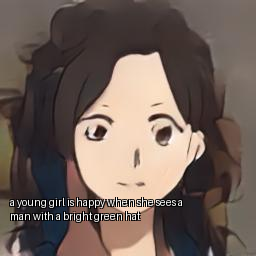

In [14]:
#Run 12
cartoonize_with_funny_caption("happy")
